In [1]:
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)


In [3]:
# ============================================================
# 2. LOAD CSV DATASET
# ============================================================

# Change this filename to your actual CSV filename.

CSV_PATH = r"C:\\KLH\\2026-2027\\Subjects\\Y25-ML\\practical\\Placement-Prediction-System\\data\\DT_Placement.csv"

df = pd.read_csv("/content/Iris (2) (1).csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df)


Dataset loaded successfully.
Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [6]:
# ============================================================
# 4. DATA PREPROCESSING
# ============================================================

# Create a copy so that the original dataset remains unchanged.
data_model = df.copy()

# ID is only an identifier and should not be used for training.
data_model = data_model.drop(columns=["Id"])

# Convert Yes/No values to 1/0.
# The Iris dataset does not contain 'Backlogs' or 'Placed' columns.
# This section is commented out as it's not applicable to the current dataset.
# mapping = {"no": 0, "yes": 1}
# for col in ["Backlogs", "Placed"]:
#     data_model[col] = data_model[col].astype(str).str.strip().str.lower().map(mapping)


# Check the result.
print("Preprocessed dataset:")
display(data_model)

print("\nData types:")
print(data_model.dtypes)

Preprocessed dataset:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica



Data types:
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object


In [8]:
# ============================================================
# 5. DEFINE X AND y
# ============================================================

X = data_model.drop(columns=["Species"])
y = data_model["Species"]

print("Features:", X.columns.tolist())
print("Target: Species")

Features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Target: Species


In [9]:
# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

Training samples: 105
Validation samples: 45

Training class distribution:
Species
Iris-versicolor    35
Iris-setosa        35
Iris-virginica     35
Name: count, dtype: int64

Validation class distribution:
Species
Iris-virginica     15
Iris-versicolor    15
Iris-setosa        15
Name: count, dtype: int64


In [10]:
# ============================================================
# 7. SINGLE DECISION TREE BASELINE
# ============================================================

dt_baseline = DecisionTreeClassifier(
        criterion="entropy",
    random_state=42
)

dt_baseline.fit(X_train, y_train)

dt_train_pred = dt_baseline.predict(X_train)
dt_val_pred = dt_baseline.predict(X_val)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_val_acc = accuracy_score(y_val, dt_val_pred)

print("SINGLE DECISION TREE")
print("=" * 50)
print(f"Training Accuracy   : {dt_train_acc:.4f}")
print(f"Validation Accuracy : {dt_val_acc:.4f}")
print(f"Tree Depth          : {dt_baseline.get_depth()}")
print(f"Number of Leaves    : {dt_baseline.get_n_leaves()}")


SINGLE DECISION TREE
Training Accuracy   : 1.0000
Validation Accuracy : 0.8889
Tree Depth          : 6
Number of Leaves    : 8


In [11]:
# ============================================================
# 8. TRAIN RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_val_acc = accuracy_score(y_val, rf_val_pred)

print("RANDOM FOREST")
print("=" * 50)
print(f"Number of Trees     : {rf.n_estimators}")
print(f"Training Accuracy   : {rf_train_acc:.4f}")
print(f"Validation Accuracy : {rf_val_acc:.4f}")
print(f"OOB Accuracy        : {rf.oob_score_:.4f}")
print(f"OOB Error           : {1 - rf.oob_score_:.4f}")

RANDOM FOREST
Number of Trees     : 100
Training Accuracy   : 1.0000
Validation Accuracy : 0.8889
OOB Accuracy        : 0.9524
OOB Error           : 0.0476


In [12]:
len(rf.estimators_)

100

In [13]:
print(rf.estimators_[0])

DecisionTreeClassifier(criterion='entropy', max_features='sqrt',
                       random_state=1608637542)


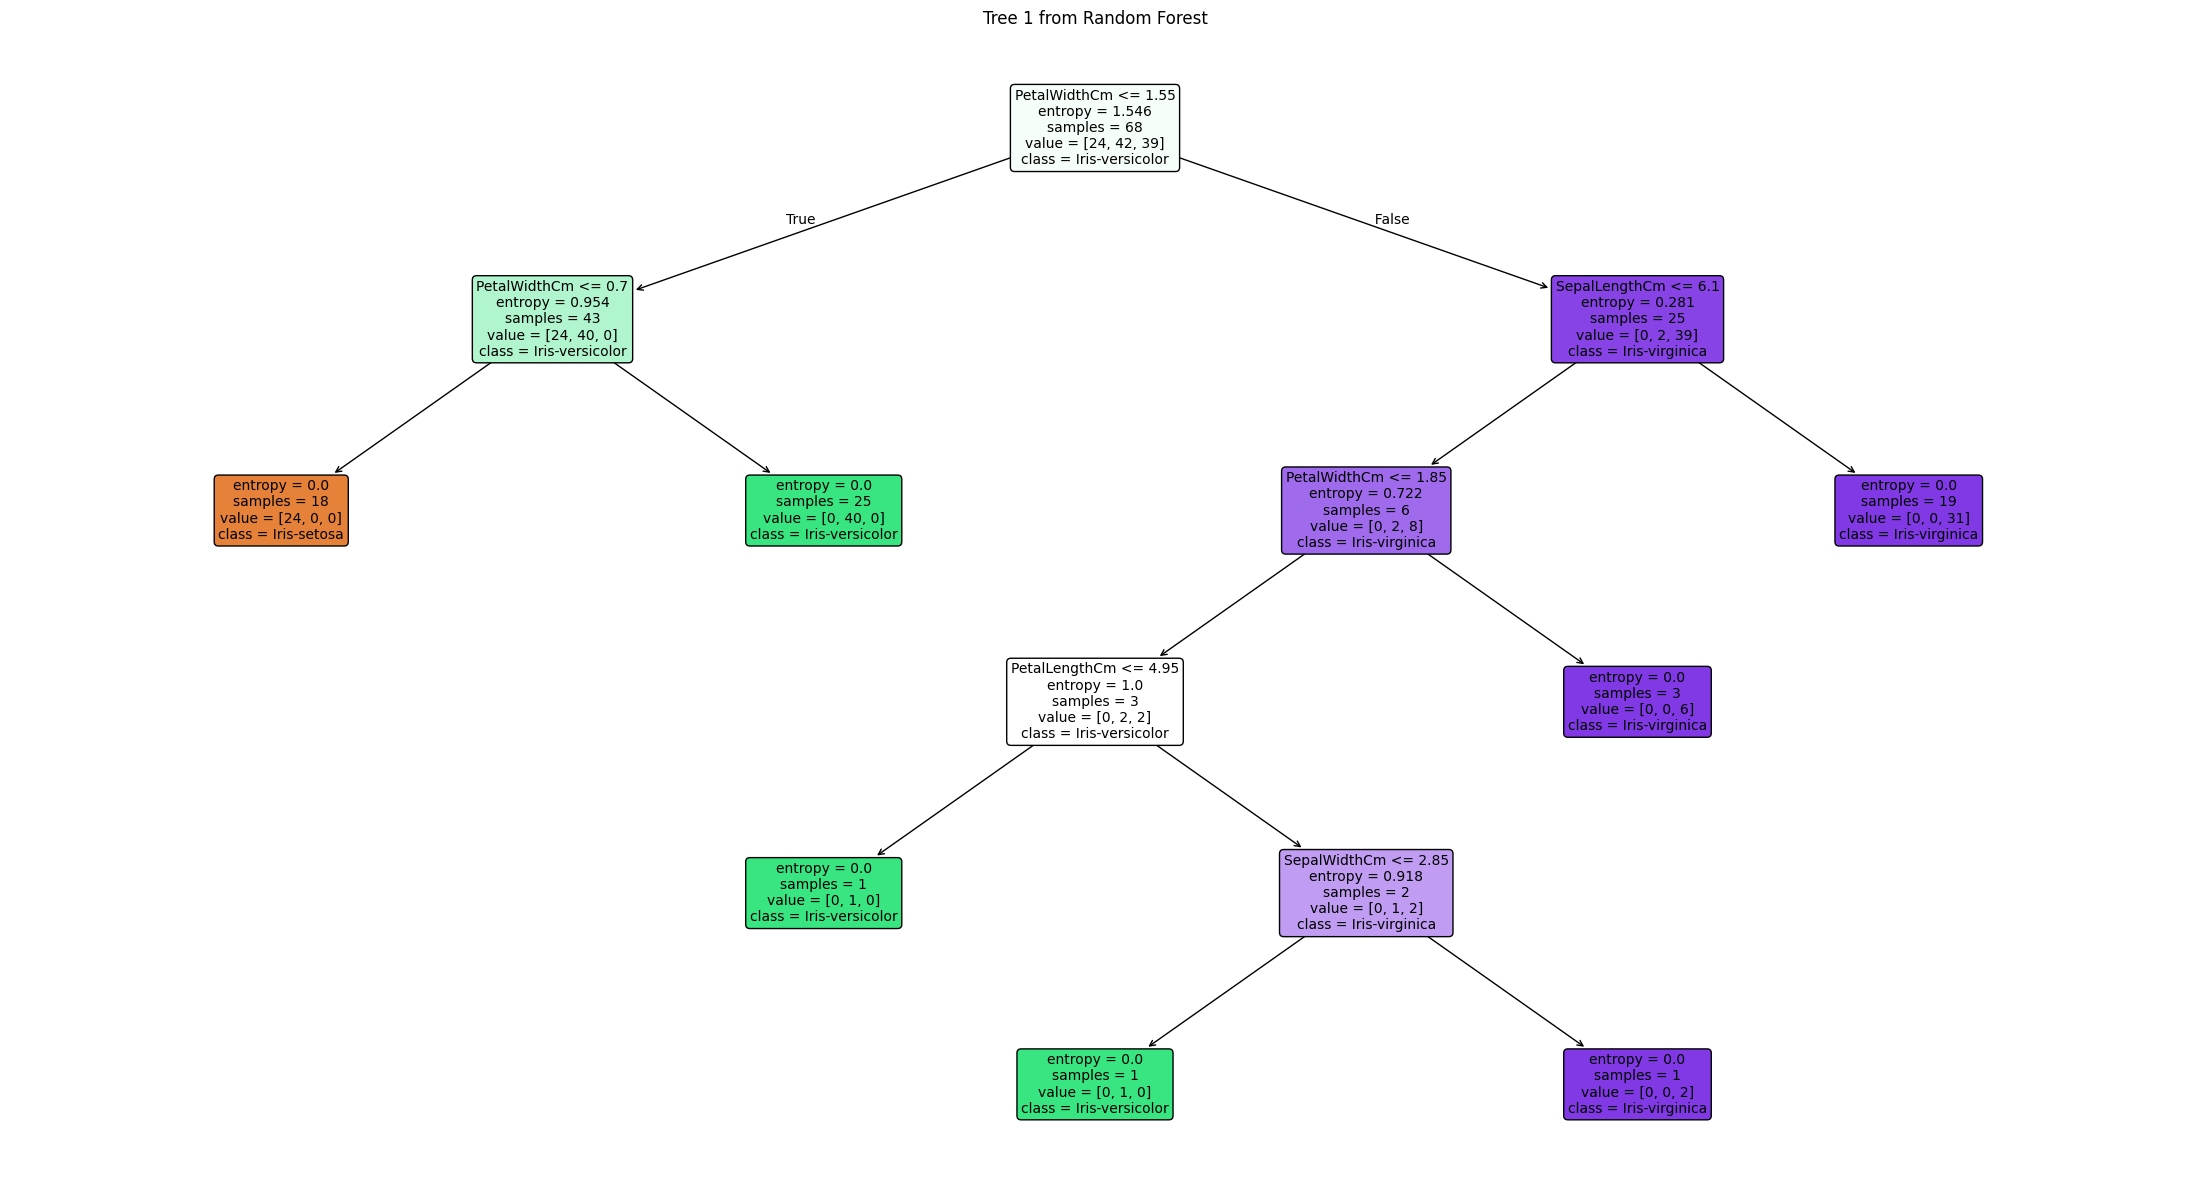

In [15]:
# ============================================================
# IMPORT plot_tree
# ============================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=rf.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Tree 1 from Random Forest")
plt.tight_layout()
plt.show()

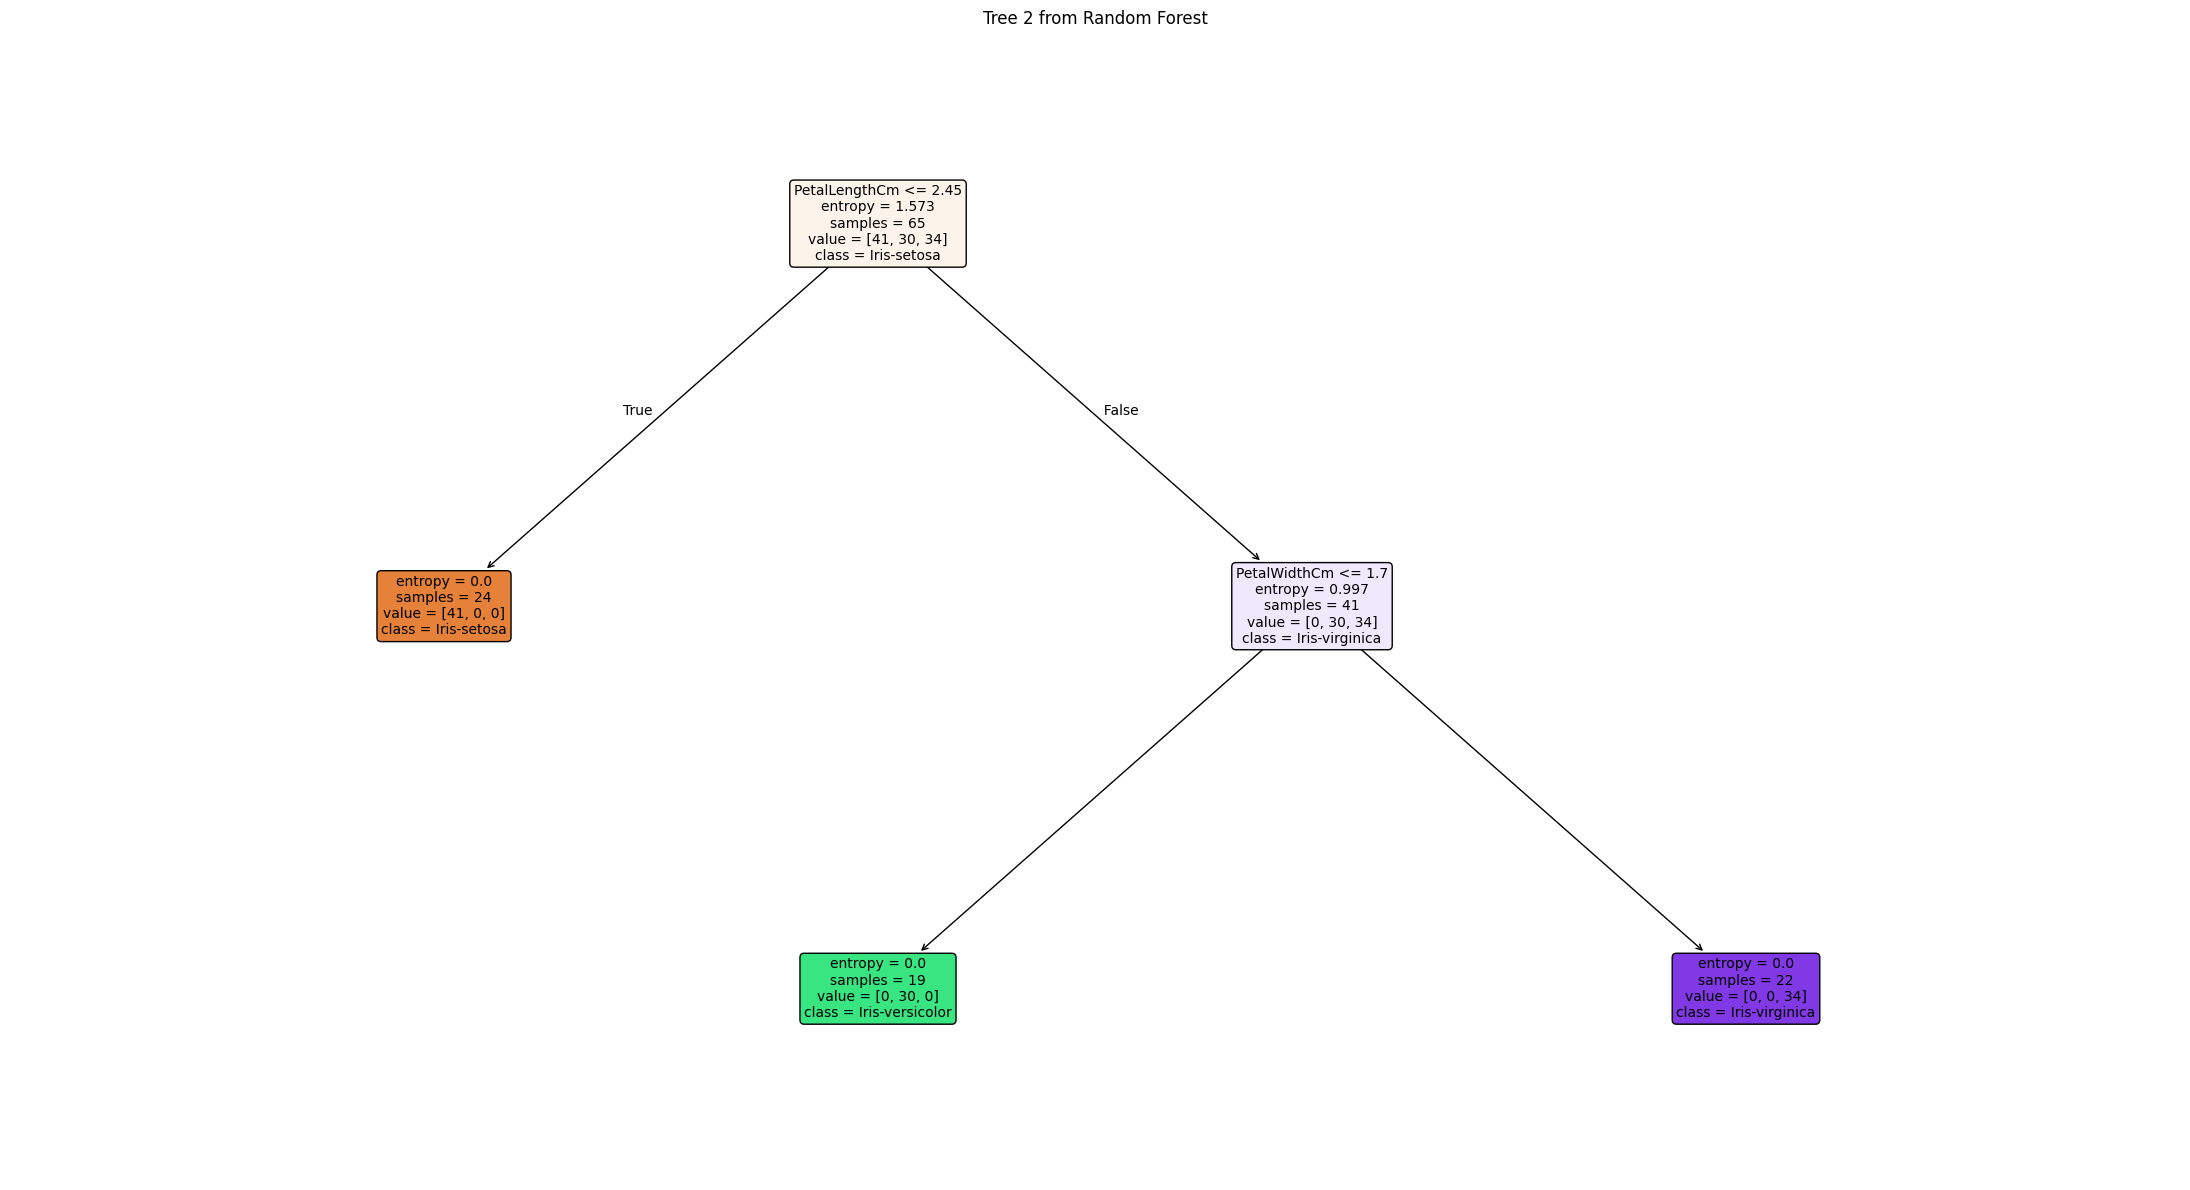

In [17]:
plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[1],
    feature_names=X.columns,
    class_names=rf.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Tree 2 from Random Forest")
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# 9. RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_val,
    rf_val_pred,
    target_names=rf.classes_,
    zero_division=0
))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.78      0.93      0.85        15
 Iris-virginica       0.92      0.73      0.81        15

       accuracy                           0.89        45
      macro avg       0.90      0.89      0.89        45
   weighted avg       0.90      0.89      0.89        45



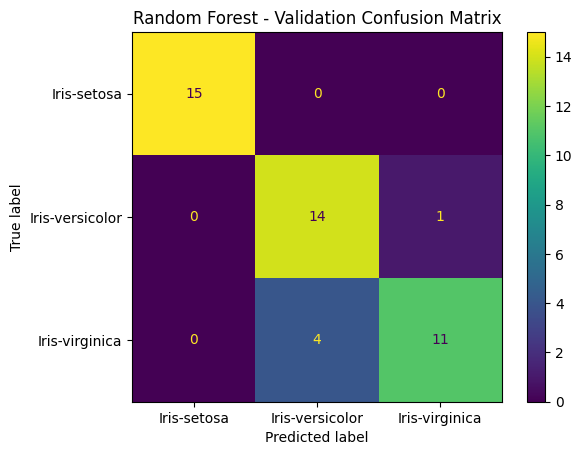

In [21]:
# ============================================================
# 10. RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_val, rf_val_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf.classes_
).plot()

plt.title("Random Forest - Validation Confusion Matrix")
plt.show()

In [22]:
# ============================================================
# 11. OOB ERROR CONVERGENCE
# ============================================================

n_estimators_values = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

oob_results = []

for n in n_estimators_values:

    model = RandomForestClassifier(
        n_estimators=n,
        criterion="entropy",
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    oob_acc = model.oob_score_

    oob_results.append({
        "n_estimators": n,
        "OOB_acc": oob_acc,
        "OOB_error": 1 - oob_acc
    })

oob_df = pd.DataFrame(oob_results)

display(oob_df.round(4))

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,OOB_acc,OOB_error
0,1,0.5143,0.4857
1,5,0.8857,0.1143
2,10,0.9714,0.0286
3,20,0.9619,0.0381
4,30,0.9619,0.0381
5,50,0.9524,0.0476
6,75,0.9524,0.0476
7,100,0.9524,0.0476
8,150,0.9524,0.0476
9,200,0.9524,0.0476


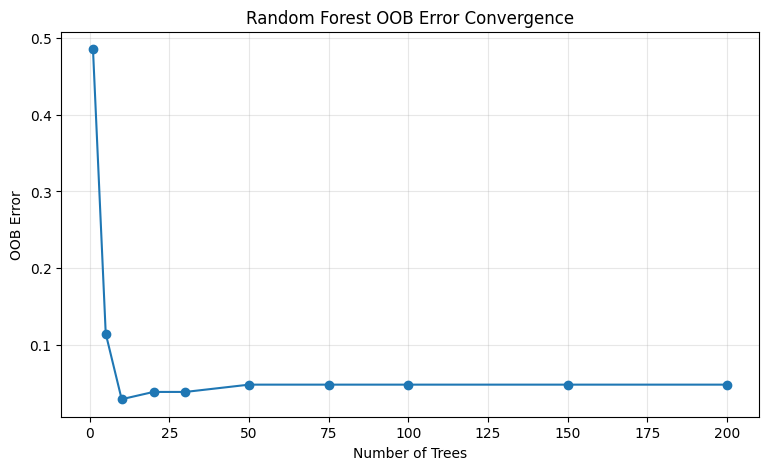

In [23]:
# ============================================================
# 12. PLOT OOB ERROR CONVERGENCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    oob_df["n_estimators"],
    oob_df["OOB_error"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error Convergence")
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
# ============================================================
# 13. COMPARE max_features
# ============================================================

max_features_values = ["sqrt", "log2", None]
max_features_results = []

for mf in max_features_values:

    model = RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_features=mf,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    max_features_results.append({
        "max_features": str(mf),
        "Train_Accuracy": accuracy_score(y_train, train_pred),
        "Validation_Accuracy": accuracy_score(y_val, val_pred),
        "OOB_Accuracy": model.oob_score_,
        "OOB_Error": 1 - model.oob_score_
    })

max_features_df = pd.DataFrame(max_features_results)

display(max_features_df.round(4))

,max_features,Train_Accuracy,Validation_Accuracy,OOB_Accuracy,OOB_Error
0,sqrt,1.0,0.8889,0.9524,0.0476
1,log2,1.0,0.8889,0.9524,0.0476
2,None,1.0,0.9333,0.9524,0.0476


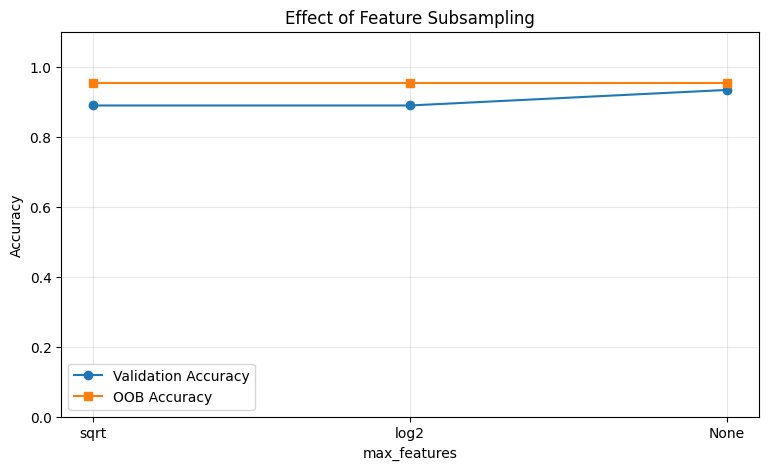

In [25]:
# ============================================================
# 14. PLOT max_features COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    max_features_df["max_features"],
    max_features_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    max_features_df["max_features"],
    max_features_df["OOB_Accuracy"],
    marker="s",
    label="OOB Accuracy"
)

plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Subsampling")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.show()


In [26]:
# ============================================================
# 15. MANUAL BOOTSTRAP SAMPLE
# ============================================================

rng = np.random.default_rng(42)

indices = rng.choice(
    np.arange(len(X_train)),
    size=len(X_train),
    replace=True
)

oob_indices = np.setdiff1d(
    np.arange(len(X_train)),
    np.unique(indices)
)

print("Bootstrap indices:")
print(indices)

print("\nUnique selected rows:")
print(np.unique(indices))

print("\nOOB row indices:")
print(oob_indices)

print("\nTotal bootstrap observations:", len(indices))
print("Unique observations:", len(np.unique(indices)))
print("OOB observations:", len(oob_indices))

Bootstrap indices:
[  9  81  68  46  45  90   9  73  21   9  55 102  77  79  75  82  53  13
  88  47  52  38  19  97  82  67  42  86  57  46  47  23   9  58  93   6
  90  86  29  66  17  79  73  37   7 101  46  93  71  81  79  20  38  49
  52   4  57  16  78  71  96  78  38 101  43  34  95  38   8  49  83  19
  48  13  72  49  34  23  59  70  98  45  16  87  66  73  10  32  80  87
  45  84  88  40  94  30  25  71  66  14  87  20  84   0  83]

Unique selected rows:
[  0   4   6   7   8   9  10  13  14  16  17  19  20  21  23  25  29  30
  32  34  37  38  40  42  43  45  46  47  48  49  52  53  55  57  58  59
  66  67  68  70  71  72  73  75  77  78  79  80  81  82  83  84  86  87
  88  90  93  94  95  96  97  98 101 102]

OOB row indices:
[  1   2   3   5  11  12  15  18  22  24  26  27  28  31  33  35  36  39
  41  44  50  51  54  56  60  61  62  63  64  65  69  74  76  85  89  91
  92  99 100 103 104]

Total bootstrap observations: 105
Unique observations: 64
OOB observations: 41


In [27]:
# ============================================================
# 16. MANUAL BAGGING: TRAIN MANY BOOTSTRAPPED TREES
# ============================================================

N_MANUAL_TREES = 50

manual_trees = []
rng = np.random.default_rng(42)

for tree_number in range(N_MANUAL_TREES):

    # Draw a bootstrap sample from training rows.
    sample_indices = rng.choice(
        np.arange(len(X_train)),
        size=len(X_train),
        replace=True
    )

    X_boot = X_train.iloc[sample_indices]
    y_boot = y_train.iloc[sample_indices]

    tree = DecisionTreeClassifier(
        criterion="entropy",
        random_state=tree_number
    )

    tree.fit(X_boot, y_boot)
    manual_trees.append(tree)

print(f"{N_MANUAL_TREES} manually bagged trees trained.")

50 manually bagged trees trained.


In [30]:
# ============================================================
# 17. MANUAL BAGGING: MAJORITY VOTE
# ============================================================

# Each tree predicts the validation students.
tree_predictions = np.array([
    tree.predict(X_val)
    for tree in manual_trees
])

# Import Counter for majority voting
from collections import Counter

# Majority vote across all trees.
# For each sample, find the most frequent class predicted by the individual trees.
manual_bagging_pred = []
# tree_predictions shape is (N_MANUAL_TREES, len(X_val))
# Iterate over each validation sample (columns in tree_predictions)
for i in range(tree_predictions.shape[1]):
    # Get all predictions for the i-th validation sample from all trees
    predictions_for_sample_i = tree_predictions[:, i]
    # Count occurrences of each unique prediction
    counts = Counter(predictions_for_sample_i)
    # The most common prediction is the majority vote
    manual_bagging_pred.append(counts.most_common(1)[0][0])

manual_bagging_pred = np.array(manual_bagging_pred)

manual_bagging_acc = accuracy_score(
    y_val,
    manual_bagging_pred
)

print(
    "Manual Bootstrap Bagging Validation Accuracy:",
    f"{manual_bagging_acc:.4f}"
)

Manual Bootstrap Bagging Validation Accuracy: 0.9556


In [29]:
# ============================================================
# 18. BAGGING CLASSIFIER
# ============================================================

# Compatible with newer scikit-learn versions.
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

bagging_train_pred = bagging.predict(X_train)
bagging_val_pred = bagging.predict(X_val)

print("BAGGING PERFORMANCE")
print("=" * 50)
print(f"Training Accuracy   : {accuracy_score(y_train, bagging_train_pred):.4f}")
print(f"Validation Accuracy : {accuracy_score(y_val, bagging_val_pred):.4f}")

BAGGING PERFORMANCE
Training Accuracy   : 1.0000
Validation Accuracy : 0.9556


In [31]:
# ============================================================
# 19. PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Mean_Importance": perm.importances_mean,
    "Std_Importance": perm.importances_std
}).sort_values(
    "Mean_Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.round(4))


,Feature,Mean_Importance,Std_Importance
0,PetalLengthCm,0.1607,0.0400
1,PetalWidthCm,0.1370,0.0340
2,SepalWidthCm,-0.0030,0.0076
3,SepalLengthCm,-0.0185,0.0142


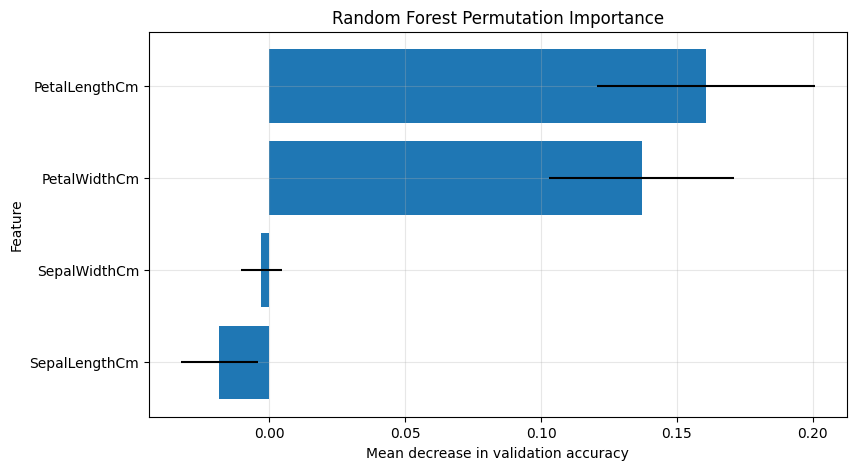

In [32]:
# ============================================================
# 20. PLOT PERMUTATION IMPORTANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Mean_Importance"],
    xerr=importance_df["Std_Importance"]
)

plt.xlabel("Mean decrease in validation accuracy")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Importance")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
# ============================================================
# 21. rf_vs_single_tree() FUNCTION
# ============================================================

def rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
):
    """Compare Random Forest with one Decision Tree.

    Returns:
        DataFrame with columns:
        n_estimators, RF_val_acc, DT_val_acc, OOB_acc

    Also plots three lines:
        1. Random Forest validation accuracy
        2. Single Decision Tree validation accuracy
        3. Random Forest OOB accuracy
    """

    results = []

    # --------------------------------------------------------
    # Train one fixed Decision Tree baseline.
    # --------------------------------------------------------
    dt = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )

    dt.fit(X_train, y_train)

    dt_val_acc = accuracy_score(
        y_val,
        dt.predict(X_val)
    )

    # --------------------------------------------------------
    # Train Random Forests with different numbers of trees.
    # --------------------------------------------------------
    for n in n_estimators_list:

        rf_model = RandomForestClassifier(
            n_estimators=n,
            criterion="entropy",
            max_features="sqrt",
            bootstrap=True,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_train, y_train)

        rf_val_acc = accuracy_score(
            y_val,
            rf_model.predict(X_val)
        )

        oob_acc = rf_model.oob_score_

        results.append({
            "n_estimators": n,
            "RF_val_acc": rf_val_acc,
            "DT_val_acc": dt_val_acc,
            "OOB_acc": oob_acc
        })

    results_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Plot the three requested lines.
    # --------------------------------------------------------
    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["n_estimators"],
        results_df["RF_val_acc"],
        marker="o",
        label="Random Forest Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["DT_val_acc"],
        marker="s",
        label="Single Decision Tree Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["OOB_acc"],
        marker="^",
        label="Random Forest OOB Accuracy"
    )

    plt.xlabel("Number of Trees (n_estimators)")
    plt.ylabel("Accuracy")
    plt.title("Random Forest vs Single Decision Tree")
    plt.legend()
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


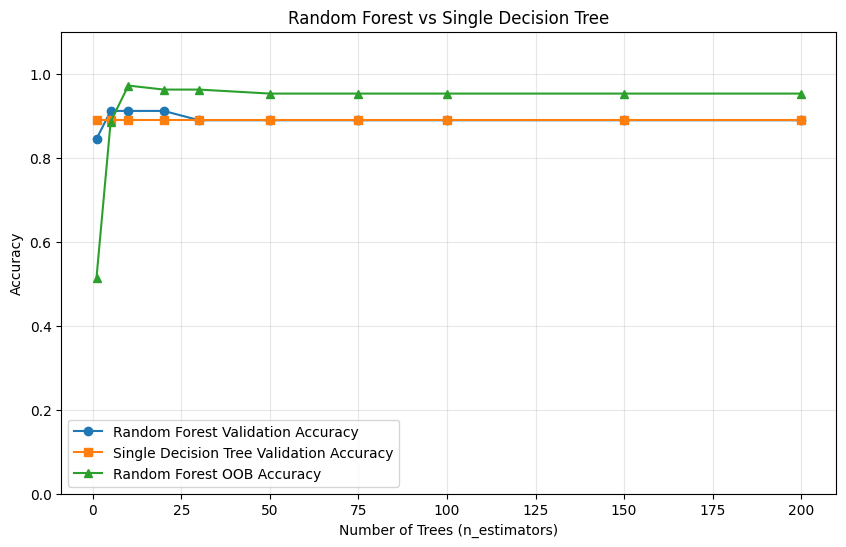

,n_estimators,RF_val_acc,DT_val_acc,OOB_acc
0,1,0.8444,0.8889,0.5143
1,5,0.9111,0.8889,0.8857
2,10,0.9111,0.8889,0.9714
3,20,0.9111,0.8889,0.9619
4,30,0.8889,0.8889,0.9619
5,50,0.8889,0.8889,0.9524
6,75,0.8889,0.8889,0.9524
7,100,0.8889,0.8889,0.9524
8,150,0.8889,0.8889,0.9524
9,200,0.8889,0.8889,0.9524


In [34]:
# ============================================================
# 22. RUN THE FUNCTION
# ============================================================

n_estimators_list = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

rf_dt_results = rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
)

display(rf_dt_results.round(4))


In [35]:
# ============================================================
# 23. BEST RANDOM FOREST SIZE
# ============================================================

best_rf_row = rf_dt_results.loc[
    rf_dt_results["RF_val_acc"].idxmax()
]

print("Best Random Forest result based on validation accuracy:")
print("=" * 65)
print(best_rf_row.to_string())

Best Random Forest result based on validation accuracy:
n_estimators    5.000000
RF_val_acc      0.911111
DT_val_acc      0.888889
OOB_acc         0.885714
